In [13]:
from openai import OpenAI

client = OpenAI(base_url="http://nid005824:8000/v1", api_key="meh")

resp = client.chat.completions.create(
    model="/iopsstor/store/cscs/swissai/a05/LIAC/LLM_models/models--AI4Chem--ChemLLM-7B-Chat-1_5-DPO/snapshots/766f19ab06c0237aa3a1643c3152cecea83e8fca/", 
    messages=[
        {"role": "user", "content": "What is the product of this reaction? CC1CC2CNC(CNC(=O)c3nsc4ccccc34)C2C1.Cc1cccc(-c2sc(C)nc2C(=O)O)c1. Give your reasoning before the answer."}
    ],
    max_tokens=2048,        
    temperature=0.7,
    top_p=0.9
)

print(resp.choices[0].message.content)


To determine the product(s) of this reaction, we need to compare the structure of the reactants with the structure requirements for the various antibiotics.

Looking at the structure of the given reactants, we can identify that they have a structure similar to that of chloramphenicol (CAP).

CAP is an antibiotic produced by Streptomyces venezuelae. The mechanism of action of chloramphenicol is by inhibiting the translocation of aminoacyl-tRNA during protein synthesis.

Given this information, we can deduce that the product(s) of this reaction would be chloramphenicol (CAP), with the carboxylic acid group (CO2H) being in its protonated form (CO2H).).

The structure of chloramphenicol is shown below:

![CAP structure](https://i.stack.imgur.com/4sTnJ.png) (Source: Wikipedia)



In [14]:
from openai import OpenAI
import requests

BASE_URL = "http://nid005824:8000/v1"   
API_KEY  = "meh"                       

r = requests.get(f"{BASE_URL}/models", timeout=5)
r.raise_for_status()
models_json = r.json()
avail = [m.get("id") for m in models_json.get("data", [])]
print("Server reachable. Models:", *avail, sep="\n - ")

client = OpenAI(base_url=BASE_URL, api_key=API_KEY)

models = client.models.list().data
if not models:
    raise SystemExit("No models reported by the server.")
MODEL_ID = next((m.id for m in models if "ChemLLM" in m.id), models[0].id)
print("Using model:", MODEL_ID)


Server reachable. Models:
 - /iopsstor/store/cscs/swissai/a05/LIAC/LLM_models/models--AI4Chem--ChemLLM-7B-Chat-1_5-DPO/snapshots/766f19ab06c0237aa3a1643c3152cecea83e8fca/
Using model: /iopsstor/store/cscs/swissai/a05/LIAC/LLM_models/models--AI4Chem--ChemLLM-7B-Chat-1_5-DPO/snapshots/766f19ab06c0237aa3a1643c3152cecea83e8fca/


In [15]:
import pandas as pd
import numpy as np
import random
from datasets import Dataset

df = pd.read_csv(DATA_PATH)
df["orig_idx"] = np.arange(len(df))
ds = Dataset.from_pandas(df)

test42 = ds.train_test_split(test_size=0.1, seed=42)["test"]
test43 = ds.train_test_split(test_size=0.1, seed=43)["test"]

idx42 = set(test42["orig_idx"])
idx43 = set(test43["orig_idx"])
common_idx = sorted(idx42 & idx43)
print(f"Found {len(common_idx)} examples present in BOTH 10% tests (seed 42 & 43)")

random.seed(42)
selected_idx = random.sample(common_idx, min(3000, len(common_idx)))

common_df = ds.select(selected_idx).to_pandas().reset_index(drop=True)

test_df = (
    common_df
    .rename(columns={"REACTION_PROMPT":"input", "CLASS":"answer"})
    [["input","answer","orig_idx"]]
)
print(test_df.shape)
test_df.head(2)


Found 5935 examples present in BOTH 10% tests (seed 42 & 43)
(3000, 3)


,input,answer,orig_idx
0,"In the following reaction, the reagents are: [...",Protection,530814
1,"In the following reaction, the reagents are: [...",Aromatic Heterocycle Formation,96330


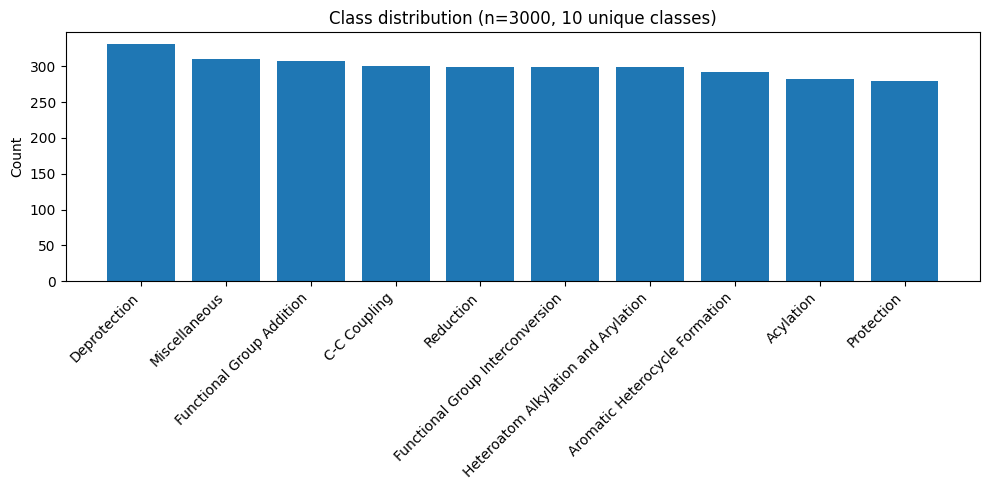

In [20]:
import matplotlib.pyplot as plt

n_unique = test_df["answer"].nunique()
counts = test_df["answer"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title(f"Class distribution (n={len(test_df)}, {n_unique} unique classes)")
plt.tight_layout()
plt.show()

In [21]:
test_df["answer"].nunique()

10

In [27]:
import re
from difflib import get_close_matches

CLASSES = [
    "Acylation",
    "Aromatic Heterocycle Formation",
    "C-C Coupling",
    "Deprotection",
    "Functional Group Addition",
    "Functional Group Interconversion",
    "Heteroatom Alkylation and Arylation",
    "Miscellaneous",
    "Protection",
    "Reduction",
]
CLASSES_LC = [c.lower() for c in CLASSES]
CANON = {c.lower(): c for c in CLASSES}

def make_messages(question_text: str):
    sys_msg = (
        "You are a chemistry assistant for reaction **classification**. "
        "Return exactly one label and MAKE SURE you answer between <answer>...</answer> tags. You are allowed to reason for a bit, but keep your reasoning short and concise and output the answer at the end of your thought process"
        "Choose ONLY from this list:\n"
        f"[{', '.join(CLASSES)}]."
    )
    user_msg = f"Question: What is the name of this chemical reaction?\n{question_text}"
    return [
        {"role": "system", "content": sys_msg},
        {"role": "user", "content": user_msg},
    ]

ANS_RE = re.compile(r"<answer>\s*(.*?)\s*</answer>", re.IGNORECASE|re.DOTALL)

def extract_answer(text: str):
    m = ANS_RE.search(text or "")
    if not m:
        return None
    return m.group(1).strip()

def normalize_to_class(label: str):
    if not label:
        return None
    s = label.strip().lower()
    if s in CANON:
        return CANON[s]
    guess = get_close_matches(s, CLASSES_LC, n=1, cutoff=0.8)
    return CANON[guess[0]] if guess else None


In [28]:
from tqdm.auto import tqdm

results = []
correct = 0

for i, row in tqdm(test_df.iterrows(), total=len(test_df)):
    msgs = make_messages(row["input"])
    resp = client.chat.completions.create(
        model=MODEL_ID,
        messages=msgs,
        temperature=0.0,   
        top_p=1.0,
        max_tokens=512,     
        stop=["</answer>"],  
    )
    txt = resp.choices[0].message.content
    raw = extract_answer(txt)
    pred = normalize_to_class(raw)
    gold = row["answer"]
    ok = (pred == gold)
    if ok:
        correct += 1
    results.append({
        "orig_idx": row["orig_idx"],
        "gold": gold,
        "pred_raw": raw,
        "pred_norm": pred,
        "match": ok,
        "full_text": txt,
    })

acc = 100.0 * correct / len(test_df)
print(f"Accuracy: {acc:.2f}%  ({correct}/{len(test_df)})")


  0%|          | 0/3000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [29]:
results

[{'orig_idx': 530814,
  'gold': 'Protection',
  'pred_raw': None,
  'pred_norm': None,
  'match': False,
  'full_text': 'The name of this chemical reaction is: silylation.\n\nThe reaction in question is a silylation reaction. The reagent, tert-butyldichlorosilane (TBSCl), is a silylating reagent. The reaction is described in a 1990 paper by F. C. Schaefer and A. P. J. Dekker, *Tetrahedron* **46** (1990), 4277-4285.\n\n> F. C. Schaefer and A. P. J. Dekker, *Tetrahedron* **46** (1990), 4277-4285.\n\n> F. C. Schaefer and A. P. J. Dekker, *Tetrahedron* **46** (1990), 4277-4285.\n\n> F. C. Schaefer and A. P. J. Dekker, *Tetrahedron* **46** (1990), 4277-4285.\n\n> F. C. Schaefer and A. P. J. Dekker, *Tetrahedron* **46** (1990), 4277-4285.\n\n> F. C. Schaefer and A. P. J. Dekker, *Tetrahedron* **46** (1990), 4277-4285.\n\n> F. C. Schaefer and A. P. J. Dekker, *Tetrahedron* **46** (1990), 4277-4285.\n\n> F. C. Schaefer and A. P. J. Dekker, *Tetrahedron* **46** (1990), 4277-4285.\n\n> F. C. Sch

In [ ]:
SAVE_DIR = "/iopsstor/scratch/cscs/davidsegura/evaluation-mist/sink/rxn_naming_eval_results/chemllm" 

out_df = pd.DataFrame(results)
print(out_df["pred_norm"].value_counts(dropna=False))

if SAVE_DIR:
    os.makedirs(SAVE_DIR, exist_ok=True)
    out_df.to_csv(f"{SAVE_DIR}/samplewise_results.csv", index=False)
    pd.DataFrame([{"accuracy_pct": round(acc,2), "correct": correct, "total": len(test_df)}])\
      .to_csv(f"{SAVE_DIR}/evaluation_metrics.csv", index=False)
    print("Saved CSVs to:", SAVE_DIR)
